In [55]:
import math
import os
import random
import sys

sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..")))
from src import *

plt.rcParams.update({'font.size': 18})
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

# Generating Torque Margin Predictions

The PyKAN trained in 2.2 is here loaded and used to generate predictions over the entire dataset.

## Load dataset

The entire dataset is standardized using the mean and the std of the train set that was saved by the previous notebook after the training.

In [69]:
# 1s
df_x, df_y = read_dataset(stage='regression')

# Load the means and standard deviations of the train set used to train the model
norm = pd.read_csv('results/one_time_train_norm.csv').iloc[0]
means = norm[[f'{col}_mean' for col in df_x.columns]].values
stds = norm[[f'{col}_std' for col in df_x.columns]].values
mean_y, std_y = norm['y_mean'], norm['y_std']

In [70]:
dataset_x = torch.tensor(df_x.values, dtype=torch.float32)
dataset_x = (dataset_x - torch.tensor(means,dtype=torch.float32)) / torch.tensor(stds,dtype=torch.float32)

In [64]:
pyKAN: PHMNetwork = PyKAN([[len(df_x.columns), 0], [1, 0], [2, 0]], 'regression', device='cpu')

checkpoint directory created: ./model
saving model version 0.0


In [65]:
# 1s
pyKAN.load('torque_target_final')
_, _, testset, _ = split_dataset(df_x, df_y['trq_target'], train_ratio=0.15, max=1, seed=1)
pyKAN.test(testset)

100%|██████████| 39/39 [00:00<00:00, 40.22it/s]


{'test_loss': -3.340875717309805}

In [75]:
def predict(model, batch_size=8192) -> pd.DataFrame:
    model.eval()
    predictions = []

    with torch.no_grad():
        for i in range(math.ceil(dataset_x.size(0) / batch_size)):
            x = dataset_x[i * batch_size:min(dataset_x.size(0), (i + 1) * batch_size)]
            mu, _ = model(x)
            mu = mu * std_y + mean_y #<-- De-normalization
            predictions.extend(mu.detach().numpy().tolist())
    return pd.DataFrame({'trq_target': predictions})

In [76]:
# 2s
prediction = predict(pyKAN)

## Visualizing the model's output
Just to make it easier to understand the performance of the model, the next cell randomly selects some subsequent samples and plots the model's prediction against the ground truth.

Text(0.5, 1.0, '$trq_{target}$ prediction')

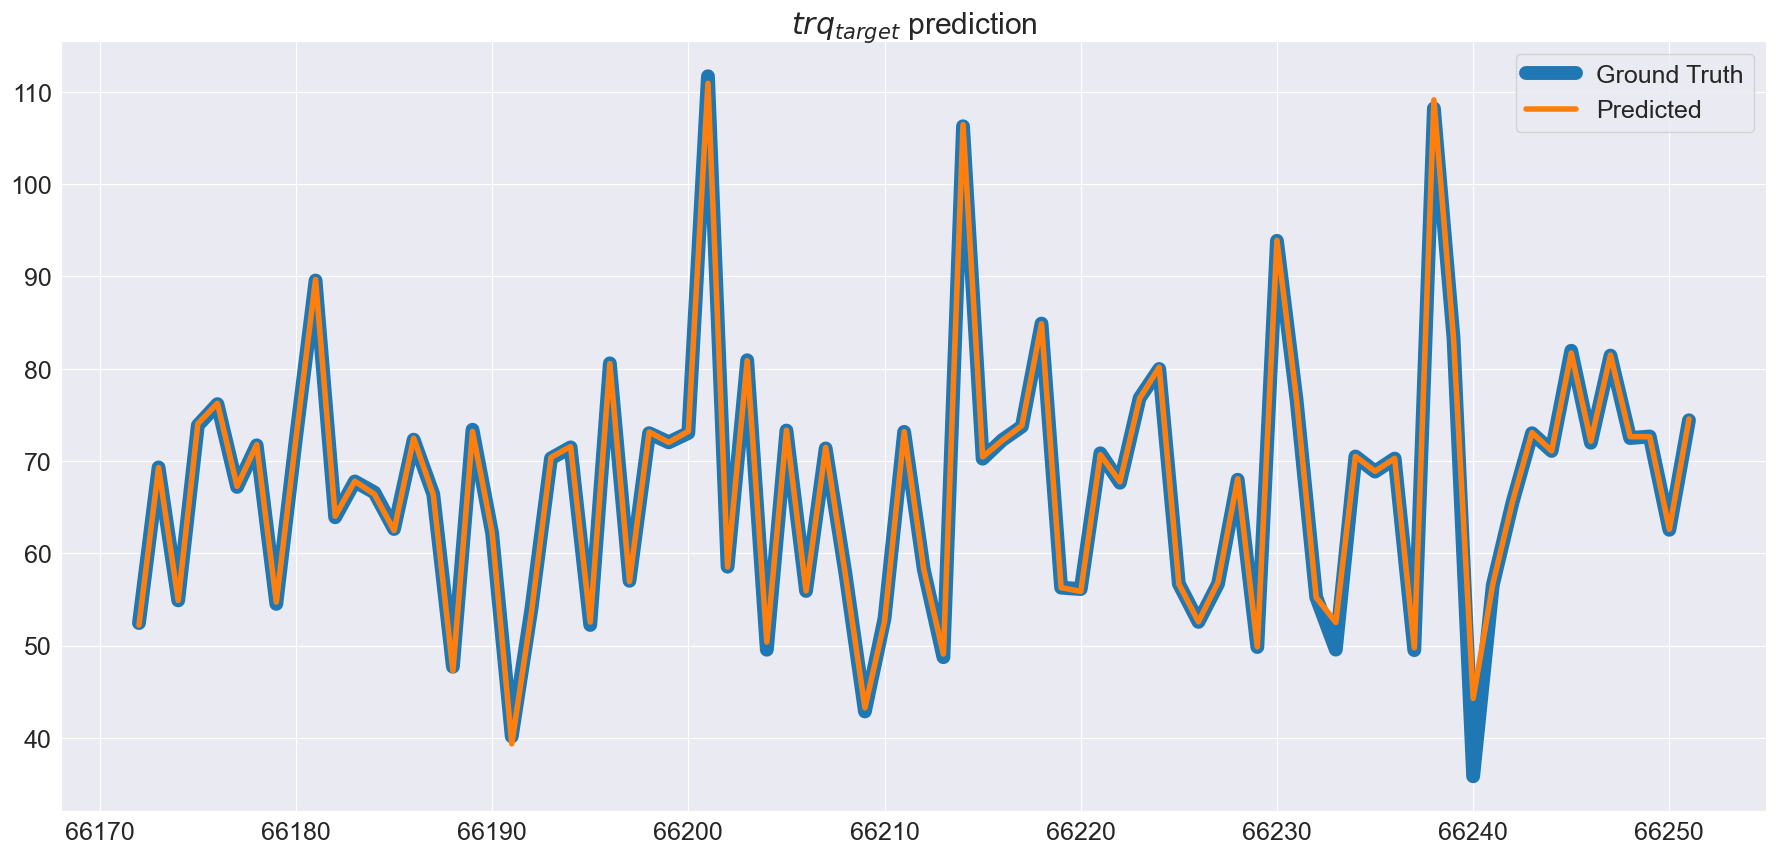

In [77]:
LENGTH = 80
i = random.randint(0, len(df_y) - LENGTH)
ax = df_y['trq_target'][i:i + LENGTH].plot(figsize=(22, 10), linewidth=10, label='Ground Truth')
prediction['trq_target'][i:i + LENGTH].plot(ax=ax, linestyle='-', linewidth=4, label='Predicted')
ax.legend()
ax.set_title('$trq_{target}$ prediction')

The $trq_{margin}$ is the input to the classifier, so here we compute it from the predicted $trq_{target}$.
$$trq_{margin}=\left(\dfrac{trq_{measured}}{trq_{target}}-1 \right)\times 100$$

In [79]:
prediction['trq_margin'] = np.where(
    prediction['trq_target'] != 0,
    (df_x['trq_measured'] / prediction['trq_target'] - 1) * 100,
    0
)
prediction = prediction.replace('unset', 0).astype(float)
prediction.to_csv('predictions.csv', index=False)